# **Tugas Akhir IF5250 Deep Learning**

# **Audio-CRNN-Benchmarking-ESC-50**

||Identitas|
|--|--|
|Nama|Siti Ramadina Goethe K.|
|NIM|15322001|
|Kode Mahasiswa|MHS-06|
|Dataset|[ESC-50](https://github.com/karolpiczak/ESC-50)|

# Bagian 1:  Persiapan Awal

## 1.1 Import Libraries & Setup Random Seed

In [ ]:
import os
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchaudio
import torch.nn.functional as F
import torchaudio.functional as AF
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"CUDA avalailable: {torch.cuda.is_available()}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print("Setup complete.")

CUDA avalailable: False
PyTorch version: 2.11.0+cpu
Device: cpu
Setup complete.


In [ ]:
"""
# Dictionary config.yaml untuk menyimpan hyperparameter
crnn_config = {
    # spectrum
    sample_rate =
    n_fft =
    n_mels =
    hop_length =
    win_length =
    f_max =

    # model and optimizer
    model_arch = 'crnn',
    optimizer = 'adam',

    # training
    learning_rate = 1e-3,
    batch_size = 32,
    n_epochs = ,
    normalize = ,

    # data
    trial_num =
    fold =
}

# ResNet-18
resnet8_config = {
    # spectrum
    sample_rate =
    n_fft =
    n_mels =
    hop_length =
    win_length =
    f_max =

    # model and optimizer
    model_arch = 'crnn',
    optimizer = 'adam',

    # training
    learning_rate = 1e-3,
    batch_size = 32,
    n_epochs = ,
    normalize = ,

    # data
    trial_num =
    fold =
}

# ViT Audio
vit_config = {
    # spectrum
    sample_rate =
    n_fft =
    n_mels =
    hop_length =
    win_length =
    f_max =

    # model and optimizer
    model_arch = 'crnn',
    optimizer = 'adam',

    # training
    learning_rate = 1e-3,
    batch_size = 32,
    n_epochs = ,
    normalize = ,

    # data
    trial_num =
    fold =
}
"""

SyntaxError: invalid syntax (3165830724.py, line 4)

## 1.2 Download dan Load Dataset ESC-50

In [ ]:
# Unduh otomatis dari GitHub
if not os.path.exists('ESC-50-master'):
  !wget https://github.com/karoldvl/ESC-50/archive/master.zip
  !unzip -oq master.zip
  print("Selesai mengunduh dataset ESC-50 dari GitHub")
else:
  print("Dataset ESC-50 sudah tersedia.")


Dataset ESC-50 sudah tersedia.


In [ ]:
# Baca data
csv_path = '/content/ESC-50-master/meta/esc50.csv'
wav_dir_path = '/content/ESC-50-master/audio'

df = pd.read_csv(csv_path)
print(f"Total data: {len(df)} sampel")
df.head()

Total data: 2000 sampel


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


## 1.3 Konversi File Audio ke Mel-Spectogram

In [ ]:
# Konversi ke melspectogram
mel_spectogram = T.MelSpectrogram(
    sample_rate = 22050,
    n_fft = 1024,
    hop_length = 512,
    n_mels = 128,
)

# Ubah audio ke Log-Mel-Spectogram
def log_mel_spec(path):
  waveform, sample_rate = torchaudio.load(path)
  mel_spec = mel_spectogram(waveform)
  log_mel = T.AmplitudeToDB(mel_spec, top_db=80)(mel_spec)
  return log_mel[0]

In [ ]:
# Kelas ESC-50 Dataset
class ESC50Dataset(Dataset):
  def __init__(self, df, wav_dir, transform=None, augment=False):
    self.df = df
    self.wav_dir = wav_dir
    self.transform = transform
    self.augment = augment

    # Augmentasi untuk membuat data lebih beragam pada saat training
    if self.augment:
      self.spec_aug = nn.Sequential(
          T.FrequencyMasking(freq_mask_param=15), # hapus freq acak
          T.TimeMasking(time_mask_param=40)       # hapus waktu acak
      )

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    wav_name = self.df.iloc[idx]['filename']
    label = self.df.iloc[idx]['target']
    audio_path = os.path.join(self.wav_dir, wav_name)

    # Ambil mel-spec
    mel_spec = log_mel_spec(audio_path)
    mel_spec = mel_spec.unsqueeze(0) # tambah dimensi channel (1, freq, t)

    # Penerapan augmentasi
    if self.augment:
      mel_spec = self.spec_aug(mel_spec)
    if self.transform:
      mel_spec = self.transform(mel_spec)

    return mel_spec, label

dataset = ESC50Dataset(df, wav_dir_path)

Id: 1126 | Label: 6 | Kategori: hen
Ukuran Tensor Spectogram: torch.Size([1, 128, 431]) (Ch, Mel, t)


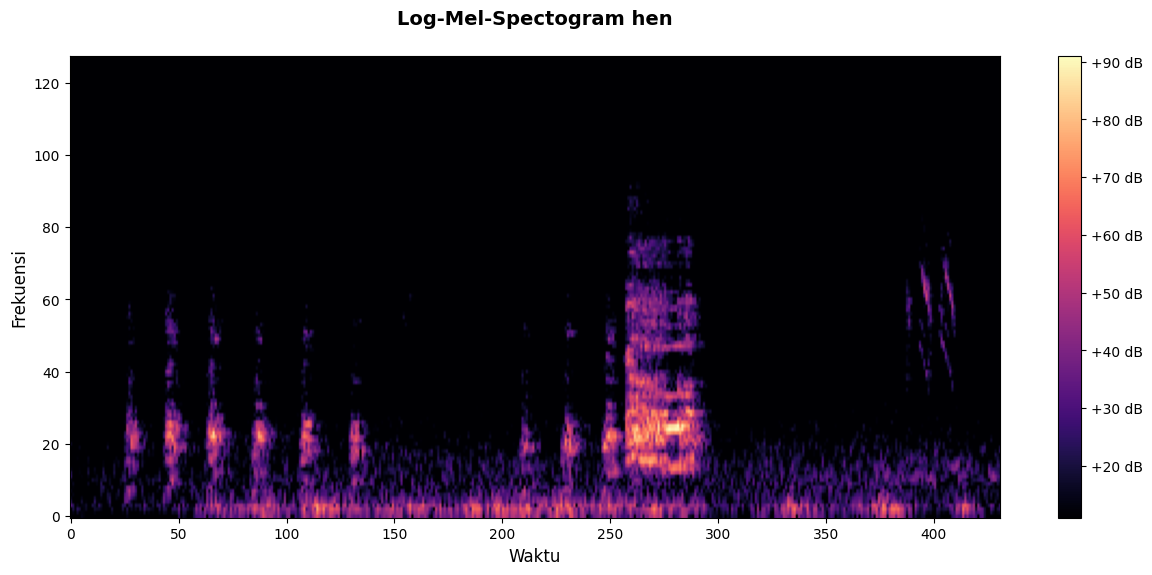

In [ ]:
# Contoh representasi visual dari suara (spektorgram)

# Pilih satu sampel acak
idx = np.random.randint(0, len(dataset))
mel, label = dataset[idx]
category = df.iloc[idx]['category']

print(f"Id: {idx} | Label: {label} | Kategori: {category}")
print(f"Ukuran Tensor Spectogram: {mel.shape} (Ch, Mel, t)")

plt.figure(figsize=(15,6))
plt.imshow(mel[0].numpy(), origin='lower', aspect='auto', cmap='magma')
plt.title(f"Log-Mel-Spectogram {category}", fontsize=14, y=1.05, fontweight='bold')
plt.xlabel("Waktu", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.colorbar(format="%+2.0f dB") # tambah satuan pada bar
plt.show()


## 1.4 Implementasi 5-Fold Cross-Validation

Fold adalah melakukan partisi data dengan jumlah yang sama besar.

In [ ]:
# Implementasi 5-Fold Cross-Validation
# Fold 1-3 train
# Fold 4 validation
# Fold 5 test

train_df = df[df['fold'].isin([1,2,3])].reset_index(drop=True)
val_df = df[df['fold']==4].reset_index(drop=True)
test_df = df[df['fold']==5].reset_index(drop=True)

## 1.5 Data Loader

In [ ]:
# DataLoader (Training, Validation, Test)
BATCH_SIZE = 32

train_dataset = ESC50Dataset(train_df, wav_dir_path, augment=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = ESC50Dataset(val_df, wav_dir_path, augment=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = ESC50Dataset(test_df, wav_dir_path, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Jumlah data latih: {len(train_df)}")
print(f"Jumlah data validasi: {len(val_df)}")
print(f"Jumlah data uji: {len(test_df)}")

# Contoh 1 batch
feat, label = next(iter(train_loader))
print(f"Ukurang bacth input: {feat.shape}")
print(f"Ukuran bacth label: {label.shape}")

Jumlah data latih: 1200
Jumlah data validasi: 400
Jumlah data uji: 400
Ukurang bacth input: torch.Size([32, 1, 128, 431])
Ukuran bacth label: torch.Size([32])


# Bagian 2: Arsitektur Model

TODO:
1. Membuat arsitektur model CRNN, ResNet18, dan ViT Audio


[Boddapati, 2017](https://github.com/bkasvenkatesh/Classifying-Environmental-Sounds-with-Image-Networks/blob/master/CRNN.py)

## 2.1 Model Utama: CRNN

In [ ]:
 # Kelas CNN dan RNN
class CRNN(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, num_classes=50):
    super(CRNN, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    # Model CNN untuk ekstraksi fitur
    # Input (B, Ch=1, f=128, t=216)
    self.cnn = nn.Sequential(
        # Layer 1
        nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2), # Out = (32, 64, 108)

        # Layer 2
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2, padding=1), # Out = (64,32,54)

        # Layer 3
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2), # Out = (128, 16,27)

        # Layer 4
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

    )

    # Model sekuensial RNN --> GRU
    self.rnn = nn.GRU(
        input_size=256*8,
        hidden_size=128,
        num_layers=2,
        dropout=0.3,
        batch_first=True,
        bidirectional=True
    )

    # Classifier
    self.dropout = nn.Dropout(0.3)
    self.classifier = nn.Linear(hidden_size*2, num_classes)

  def extract_features(self, x):
    # x shape = [b, 1, 128, 216]
    # CNN
    x = self.cnn(x)
    x = x.permute(0,3,1,2) # ubaah [batch, ch, f, t] jadi [batch, t, ch, f]
    batch, t, ch, f = x.size()
    x = x.reshape(batch, t, ch*f)

    # RNN
    gru_out, _ = self.rnn(x)
    feat = gru_out[:, -1, :]
    return feat

  def forward(self, x):
    feat = self.extract_features(x)
    feat = self.dropout(feat)
    out = self.classifier(feat)
    return out

model = CRNN(input_size=64, hidden_size=128, num_layers=2, num_classes=50)
dummy = torch.randn(4,1,128,216)
output = model(dummy)
print(output.shape)

print(f"bentuk input:{dummy.shape}")
print(f"bentuk output: {output.shape}")


torch.Size([4, 50])
bentuk input:torch.Size([4, 1, 128, 216])
bentuk output: torch.Size([4, 50])


1. Downsampling (maxpool) 4 layer --> tinggi spektogram (f) 128 px --> 8 px

128/(2.2.2.2)=8

2. Permute & reshap : putar data agar dimensi waktu menjadi urutan utama yang dibaca oleh LSTM

3. pakai bilstm agar model bisa memahami konteks suara dari depan atau blkg

4. penultimate layer: lstm_out[], akan digunakan untuk tugas rsm. isi otak model sebelum menebak kelas suara.


1. Apakah Arsitektur CRNN itu "Baku"?
Jawabannya: Tidak. CRNN hanyalah sebuah konsep hibrida (CNN + RNN). Ibarat resep nasi goreng, bumbu dasarnya sama (nasi dan kecap), tapi isi dan teknik memasaknya bisa berbeda-beda.
Variasi yang bisa Anda ubah agar model ini menjadi "milik Anda" dan unik:
Jumlah Layer CNN: Anda bisa memakai 3, 4, atau 5 layer.
Jumlah Filter: Anda bisa memakai urutan 16-32-64 atau 32-64-128-256.
Jenis RNN: Anda bisa mengganti LSTM dengan GRU (lebih ringan) atau menggunakan satu arah (unidirectional) saja.
Aktivasi: Anda bisa mengganti ReLU dengan LeakyReLU atau ELU.
Regularisasi: Menambahkan Dropout pada layer tertentu untuk mencegah overfitting.
2. Bagaimana Menyiasati Kode agar Tidak Dianggap Plagiat?
Untuk menghindari kesan copy-paste buta, lakukan langkah-langkah ini:
A. Modifikasi Parameter (Tweak)
Jangan pakai angka yang persis saya berikan. Misalnya:
Jika saya berikan kernel_size=3, Anda bisa mencoba kernel_size=5 pada layer pertama.
Jika saya berikan hidden_size=128, coba gunakan hidden_size=64 atau 256.
Tambahkan nn.Dropout(0.2) setelah layer CNN atau RNN.
B. Pahami "Mengapa"-nya dan Tulis di Laporan
Dosen biasanya tidak hanya melihat kodenya, tapi narasi Anda di Bab 3 (Metodologi) dan Bab 7 (Diskusi).
Contoh: "Saya memilih menggunakan 3 layer CNN dengan filter yang meningkat secara progresif (32, 64, 128) agar model dapat menangkap fitur spasial dari spektrogram secara hierarkis..."
Kalimat seperti ini membuktikan bahwa Anda paham, bukan sekadar menempel kode.
C. Gunakan Dokumentasi Resmi sebagai Referensi
Anda tidak perlu membaca seluruh dokumentasi PyTorch dari nol (itu akan menghabiskan waktu). Cukup gunakan sebagai "Kamus".
Jika Anda menggunakan nn.Conv2d, buka dokumentasi PyTorch Conv2d hanya untuk melihat parameter apa saja yang bisa Anda ganti.
3. Strategi "Efisiensi Waktu" yang Aman
Daripada belajar dari nol atau copy-paste total, gunakan metode "Template as a Guide":
Gunakan struktur data loader yang saya berikan: Bagian ini biasanya bersifat standar (boilerplate). Hampir semua orang menggunakan cara yang mirip untuk me-load audio. Ini risiko plagiasinya rendah karena memang cara kerjanya begitu.
Buat variasi pada kelas Model: Ubah jumlah layer atau ukuran filter sesuai poin #1 di atas.
Berikan Komentar (Comment) di Setiap Baris Kode: Tulis penjelasan dengan bahasa Anda sendiri di samping baris kode. Ini sangat membantu membuktikan orisinalitas pemikiran Anda.
Saran Praktis untuk MHS-06:
Agar arsitektur Anda berbeda dari mahasiswa lain, cobalah gunakan GRU sebagai pengganti LSTM.
Alasannya: GRU memiliki parameter lebih sedikit dan seringkali performanya setara dengan LSTM untuk tugas klasifikasi suara pendek (5 detik). Ini bisa menjadi poin menarik di laporan Anda: "Saya memilih GRU karena keterbatasan resource dan durasi audio yang singkat..."
Apakah Anda ingin saya tunjukkan bagaimana mengubah LSTM tadi menjadi GRU dan menambahkan Dropout agar modelnya lebih "khas" dan aman secara akademis?

## 2.2 Model Pembanding 1 (Baseline): ResNet-18

In [ ]:
# Adaptasi ResNet-18 untuk input spectogram (1 ch)
class ResNet18(nn.Module):
  def __init__(self, num_classes=50, pretrained=True):
    # Load model dari torchvision
    super(ResNet18, self).__init__()
    self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
    original_conv = self.resnet.conv1
    self.resnet.conv1 = nn.Conv2d(1, 64,
                                  kernel_size = original_conv.kernel_size,
                                  stride = original_conv.stride,
                                  padding = original_conv.padding,
                                  bias = False
                                  )

    with torch.no_grad():
      self.resnet.conv1.weight[:] = original_conv.weight[:, 0:1, :, :]

    num_ft = self.resnet.fc.in_features
    self.resnet.fc = nn.Linear(num_ft, num_classes)

  def forward(self, x):
    return self.resnet(x)

resnet_model = ResNet18(num_classes=50, pretrained=True).to(device)


## 2.3 Model Pembanding 2 (SOTA): ViT Audio

In [ ]:
class ViTAudio(nn.Module):
    def __init__(self, num_classes=50, pretrained=True):
        super(ViTAudio, self).__init__()

        # 1. Load ViT Base 16
        weights = models.ViT_B_16_Weights.DEFAULT if pretrained else None
        self.vit = models.vit_b_16(weights=weights)

        # 2. Modifikasi Output Layer (Heads)
        in_features = self.vit.heads.head.in_features
        self.vit.heads.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        # x shape awal: [Batch, 1, H, W]

        # A. Resize ke 224x224 (Wajib untuk ViT standar)
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)

        # B. Ubah 1 channel (Grayscale) menjadi 3 channel (RGB)
        x = x.repeat(1, 3, 1, 1)

        # C. Masukkan ke ViT
        return self.vit(x)

# Inisialisasi model
vit_model = ViTAudio(num_classes=50, pretrained=True).to(device)

# Bagian 3: Training & Validation Pipeline

TODO:
1. Membuat fungsi training umum yang dapat diterapkan pada semua model.
2. Membuat fungsi validasi umum yang dapat diterapkan pada semua model.
3. Membuat contoh loop training untuk semua model.
4. Membuat loop training sekaligus untuk semua model.
4. Visualisasi hasil seluruh pelatihan model.

## 3.1 Fungsi Training

In [ ]:
# Fungsi Training Umum
def train(model, loader, criterion, optimizer, device):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for batch_idx, (input, target) in enumerate(loader):
    input, target = input.to(device), target.to(device)

    # Mengosongkan gradien
    optimizer.zero_grad()

    # Forward pass (prediksi)
    output = model(input)

    # Menghitung loss
    loss = criterion(output, target)

    # Backward pass
    loss.backward()

    # Perbarui bobot
    optimizer.step()
    running_loss += loss.item()
    _, predicted = torch.max(output.data, 1)
    total += target.size(0)
    correct += (predicted == target).sum().item()

    epoch_loss =  running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

print("Fungsi training untuk 1 epoch telah dibuat.")

Fungsi training untuk 1 epoch telah dibuat.


## 3.2 Fungsi Validasi

In [ ]:
# Fungsi Validasi Umum
def validate(model, loader, criterion, device):
  model.eval()
  running_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
    for input, target in loader:
      input, target = input.to(device), target.to(device)
      output = model(input)
      loss = criterion(output, target)
      running_loss += loss.item()
      _, predicted = torch.max(output.data, 1)
      total += target.size(0)
      correct += (predicted == target).sum().item()

      loss = running_loss/total
      acc = 100. * correct/total

    return loss, acc

print('Fungsi validasi umum telah dibuat')

Fungsi validasi umum telah dibuat


## 3.3 Loop Training Masing-masing Model

In [ ]:
# Coba Loop Utama untuk Model CRNN

crnn_model = CRNN(input_size=64, hidden_size=128, num_layers=2, num_classes=50).to(device)
criterion = nn.CrossEntropyLoss() # fungsi loss utk klasifikasi
optimizer = optim.Adam(crnn_model.parameters(), lr=1e-3)

# Untuk menyimpan hasil
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0 # Model terbaik
epochs = 2

for epoch in range(epochs):
  train_loss, train_acc = train(crnn_model, train_loader, criterion, optimizer, device)
  val_loss, val_acc = validate(crnn_model, val_loader, criterion, device)

  history['train_loss'].append(train_loss)
  history['train_acc'].append(train_acc)
  history['val_loss'].append(val_loss)
  history['val_acc'].append(val_acc)

  print(f"Epoch {epoch+1}/{epochs} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f} |")

  # Simpan model terbaik
  if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(crnn_model.state_dict(), 'best_model.pth')
    print("Model terbaik disimpan.")
  print("-"*30)

Epoch 1/2 | Train loss: 0.1231 | Train acc: 0.00 | Val loss: 0.1269 | Val acc: 3.50 |
Model terbaik disimpan.
------------------------------
Epoch 2/2 | Train loss: 0.1222 | Train acc: 0.00 | Val loss: 0.1267 | Val acc: 4.25 |
Model terbaik disimpan.
------------------------------


In [ ]:
# Loop Utama untuk ResNet18
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
epochs = 2
best_val_acc = 0.0

# Jalankan Loop Training
resnet_history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(epochs):
    train_loss, train_acc = train(resnet_model, train_loader, criterion, resnet_optimizer, device)
    val_loss, val_acc = validate(resnet_model, val_loader, criterion, device)

    # Simpan ke history vit
    resnet_history['train_loss'].append(train_loss)
    resnet_history['train_acc'].append(train_acc)
    resnet_history['val_loss'].append(val_loss)
    resnet_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f} |")

    # Simpan model terbaik
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(resnet_model.state_dict(), 'resnet_best_model.pth')
      print("Model ResNet18 terbaik disimpan.")
    print("-"*30)


Epoch 1/2 | Train loss: 0.1287 | Train acc: 0.00 | Val loss: 0.1321 | Val acc: 2.25 |
Model ResNet18 terbaik disimpan.
------------------------------
Epoch 2/2 | Train loss: 0.1247 | Train acc: 0.00 | Val loss: 0.1314 | Val acc: 1.75 |
------------------------------


In [ ]:
#  Loop Utama untuk ViT
vit_model = ViTAudio(num_classes=50, pretrained=True).to(device)
vit_optimizer = optim.Adam(vit_model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()
epochs = 2
best_val_acc = 0.0

# Jalankan training menggunakan fungsi yang sama
vit_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    train_loss, train_acc = train(vit_model, train_loader, criterion, vit_optimizer, device)
    val_loss, val_acc = validate(vit_model, val_loader, criterion, device)

    # Simpan ke history vit
    vit_history['train_loss'].append(train_loss)
    vit_history['train_acc'].append(train_acc)
    vit_history['val_loss'].append(val_loss)
    vit_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f} |")

    # Simpan model terbaik
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(vit_model.state_dict(), 'vit_best_model.pth')
      print("Model ViT terbaik disimpan.")
    print("-"*30)

Epoch 1/2 | Train loss: 0.1262 | Train acc: 0.00 | Val loss: 0.1300 | Val acc: 3.25 |
Model ViT terbaik disimpan.
------------------------------
Epoch 2/2 | Train loss: 0.1233 | Train acc: 0.00 | Val loss: 0.1293 | Val acc: 3.25 |
------------------------------


## 3.4 Loop Training Semua Model

In [ ]:
all_model_types = ['CRNN', 'ResNet18', 'ViT']
epochs = 2

# All history to store all each model results
all_history = {
    'CRNN': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []},
    'ResNet18': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []},
    'ViT': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
}

# Loop training for each model
for model in all_model_types:
  print("="*90)
  print(f"Training {model} model")
  print("="*90)

  current_best_val_acc = 0.0

  if model == 'CRNN':
    curr_model = CRNN(input_size=64, hidden_size=128, num_layers=2, num_classes=50).to(device)
  elif model == 'ResNet18':
    curr_model = ResNet18(num_classes=50, pretrained=True).to(device)
  else: # model == "ViT"
    curr_model = ViTAudio(num_classes=50, pretrained=True).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(curr_model.parameters(), lr=1e-3)

  # Loop utama
  for epoch in range(epochs):
    train_loss, train_acc = train(curr_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(curr_model, val_loader, criterion, device)

    all_history[model]['train_loss'].append(train_loss)
    all_history[model]['train_acc'].append(train_acc)
    all_history[model]['val_loss'].append(val_loss)
    all_history[model]['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f} |")

    # Simpan checkpoint model terbaik untuk model saat ini
    if val_acc > current_best_val_acc:
      current_best_val_acc = val_acc
      torch.save(curr_model.state_dict(), f'{model}_best_model.pth')
      print(f"Model {model} terbaik disimpan.")

Training CRNN model
Epoch 1/2 | Train loss: 0.1244 | Train acc: 0.00 | Val loss: 0.1268 | Val acc: 4.25 |
Model CRNN terbaik disimpan.
Epoch 2/2 | Train loss: 0.1249 | Train acc: 3.12 | Val loss: 0.1264 | Val acc: 5.50 |
Model CRNN terbaik disimpan.
Training ResNet18 model
Epoch 1/2 | Train loss: 0.1329 | Train acc: 0.00 | Val loss: 0.1360 | Val acc: 3.50 |
Model ResNet18 terbaik disimpan.
Epoch 2/2 | Train loss: 0.1151 | Train acc: 12.50 | Val loss: 0.1520 | Val acc: 5.25 |
Model ResNet18 terbaik disimpan.
Training ViT model
Epoch 1/2 | Train loss: 0.1241 | Train acc: 0.00 | Val loss: 0.1654 | Val acc: 3.75 |
Model ViT terbaik disimpan.
Epoch 2/2 | Train loss: 0.1718 | Train acc: 0.00 | Val loss: 0.1341 | Val acc: 2.25 |


## 3.5 Visualisasi Hasil Training dan Validasi

In [ ]:
# Fungsi Visualisasi Kurva Pelatihan (Loss dan Akurasi)

def history_plot(history, model_name):
  epochs = range(1, len(history['train_loss'])+1)

  # Loss vs Epoch
  fig, axes = plt.subplots(1, 2, figsize=(12,5))
  axes[0].plot(epochs, history['train_loss'], label='Train Loss')
  axes[0].plot(epochs, history['val_loss'], label='Validation Loss')
  axes[0].set_title(f'Loss vs Epoch {model_name} Model', fontweight='bold', fontsize=14)
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Loss')
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  # Accuracy vs Epoch
  axes[1].plot(epochs, history['train_acc'], label='Train Accuracy')
  axes[1].plot(epochs, history['val_acc'], label='Validation Accuracy')
  axes[1].set_title(f'Accuracy vs Epoch {model_name} Model', fontweight='bold', fontsize=14)
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Accuracy')
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  fig.savefig(f"{model_name}_train_val_curve.png")
  plt.tight_layout()
  plt.show()

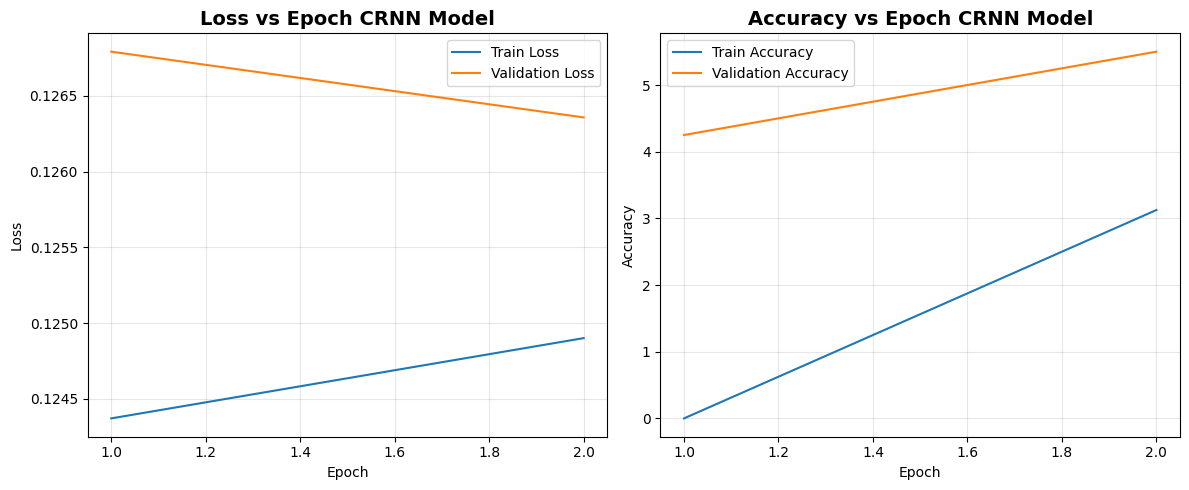

None

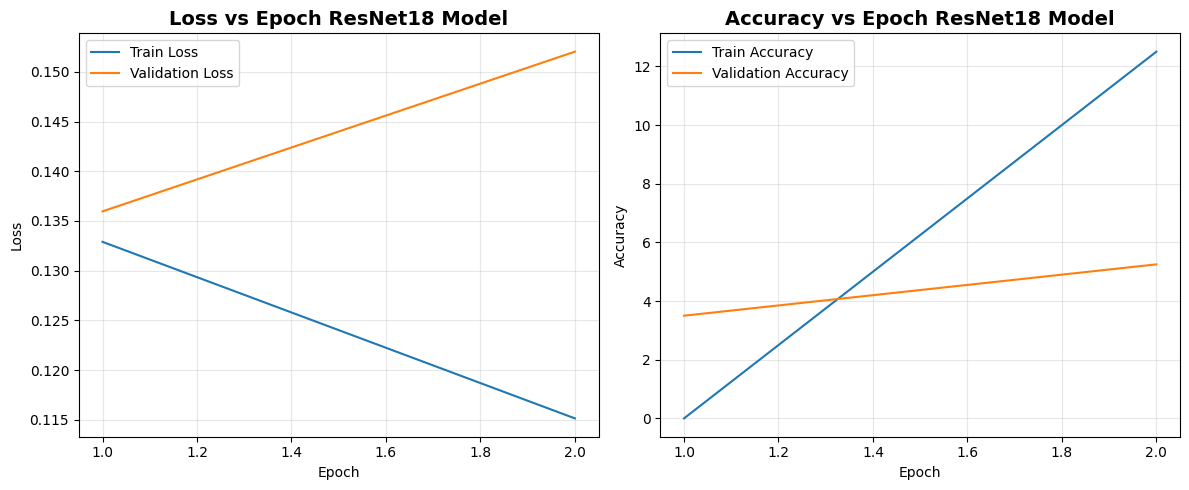

None

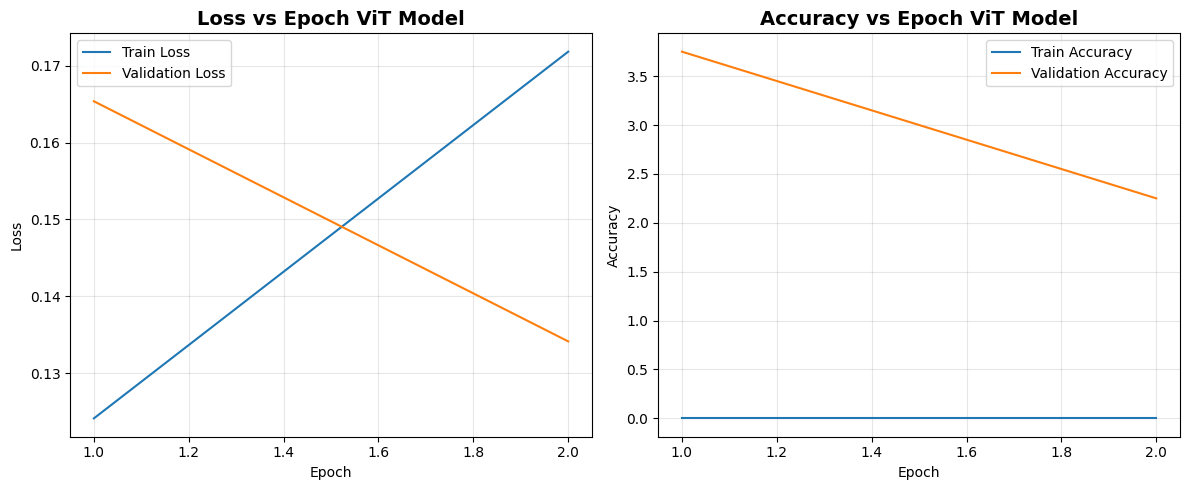

None

In [ ]:
# Visualisasi seluruh model
all_model_types = ['CRNN', 'ResNet18', 'ViT']

for model_name in all_model_types:
    vis_model = history_plot(all_history[model_name], model_name)
    display(vis_model)

# Bagian 4: Evaluasi dan Benchmarking

TODO:
1. Evaluasi semua model pada Test Set (Fold 5).
2. Hitung Accuracy, Precision, Recall, F1-Score (Weighted). --> Classification Report
3. Buat Confusion Matrix untuk ketiga model.
4. Ekspor hasil ke file metrics.json.

## 4.1 Fungsi Evaluasi

In [ ]:
# Fungsi Evaluasi (Testing) Umum
def evaluate(model, loader, criterion, device):
  model.eval()
  all_preds, all_labels = [], []
  total_loss = 0.0
  total_correct = 0
  total_samples = 0

  with torch.no_grad():
    for inputs, targets in loader:
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs)
      loss = criterion(output, targets)

      total_loss += loss.item()*targets.size(0)
      _, pred = output.max(1)
      total_correct += (pred == targets).sum().item()
      total_samples += targets.size(0)

      all_preds.extend(pred.cpu().numpy())
      all_labels.extend(targets.cpu().numpy())

  avg_loss = total_loss / total_samples
  accuracy = 100. * total_correct / total_samples

  return avg_loss, accuracy, all_preds, all_labels

## 4.2 Fungsi Visualisasi Confusion Matrix

In [ ]:
# Confusion Matrix Visualisation

def CMVis(cm, classes, model_name):
  # Normalize percente
  cm_norm = cm.astype('float')/ cm.sum(axis=1)[:, np.newaxis]
  plt.figure(figsize=(22,20))
  classes = df.sort_values('target')['category'].unique()

  # Heatmap
  sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues', xticklabels=classes, yticklabels=classes, annot_kws={"size":7}, cbar=True)
  plt.title(f'Confusion Matrix {model_name} Model', fontsize=20, fontweight='bold')
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.grid(True, alpha=0.3)

  # Label position
  plt.xticks(rotation=90)
  plt.yticks(rotation=0)

  plt.tight_layout()
  plt.savefig(f"{model_name}_confusion_matrix.png", dpi=300)
  plt.show()

## 4.3 Fungsi Pendukung untuk Evaluasi


In [ ]:
# Fungsi untuk hitung params dan waktu inferensi
def get_model_info(model, test_loader, device):
  num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
  model.eval()

  start_time = time.time()
  with torch.no_grad():
    for inputs, targets in test_loader:
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs)
      _, pred = output.max(1)
  end_time = time.time()

  d_time = end_time - start_time
  inf_time = d_time / inputs.size(0) * 1000

  return num_params, inf_time

In [ ]:
# Fungsi persiapan untuk ekspor ke metric.json
def metrics(model_name, acc, f1, best_epoch, model, test_loader, device):
  num_params, inf_time = get_model_info(model, test_loader, device)

  # Spesifikasi file metric.json
  metrics_data = {
      "model_name": model_name,
      "dataset": "ESC-50",
      "subset": "All 50 classes",
      "random_seed": 42,
      "optimizer": "Adam",
      "learning_rate": 0.001,
      "batch_size": 32,
      "epochs_total": 50,
      "best_epoch": best_epoch,
      "test_accuracy": round(acc/100, 4),
      "test_f1_weighted" : round(f1, 4),
      "num_parameters": num_params,
      "inference_time": round(inf_time, 4)
  }

  file_path = f"{model_name}_metrics.json"
  with open(file_path, 'w') as json_file:
    json.dump(metrics_data, json_file, indent=4)

  print(f"Complete saved file in {file_path}")

print("Complete made metrics function")

Complete made metrics function


# Bagian 5: Representational Similarity Analysis (RSM)

TODO:
1. Load "Benchmark Set" berisi 400 audio.
2. Mengekstrak embedding dari penultimate layer untuk setiap model.
3. Menghitung Cosine Similarity Matrix (N x N).
4. Visualisasi heatmap RSM dan menyimpannya dalam .png.

## 5.1 Benchmark Set

Ketentuan:
- 50 kelas
- 8 audio/kelas
- Total 400 audio
- 200 dari fold-4
- 200 dari fold-5

In [ ]:
# Fungsi untuk memilih 400 sampel
def benchmark_sampling(all_df):
  df_selected = all_df[all_df['fold'].isin([4,5])] # hanya fold 4 dan 5
  benchmark_list = []
  classes = 50

  # 8 sampel per kelas
  for cls in range(classes):
    sample_fold4 = df_selected[(df_selected['fold'] == 4) &
                               (df_selected['target'] == cls)].head(4) # ambil 4 sampel
    sample_fold5 = df_selected[(df_selected['fold'] == 5) &
                               (df_selected['target'] == cls)].head(4) # ambil 4 sampel

    benchmark_list.append(sample_fold4)
    benchmark_list.append(sample_fold5)

  benchmark_df = pd.concat(benchmark_list).reset_index(drop=True)
  return benchmark_df

# Menjalankan fungsi sampling
benchmark_df = benchmark_sampling(df)

# Buat loader lagi
benchmark_dataset = ESC50Dataset(benchmark_df, wav_dir_path, augment=False)
benchmark_loader = DataLoader(benchmark_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Dataset audio untuk benchmark sudah siap.")

Dataset audio untuk benchmark sudah siap.


## 5.2 Ekstrak Embedding dari Penultimate Layer

In [ ]:
# Fungsi ekstrak embedding
def extract_embedding(model, loader, model_type, device):
  model.eval()
  embeddings = []
  labels = []

  with torch.no_grad():
    for inputs, targets in loader:
      inputs = inputs.to(device)

      # Ekstraksi untuk CRNN
      if model_type == 'CRNN':
        feat = model.extract_features(inputs)
        feat = feat.view(feat.size(0), -1) # output terakhir lstm

      # Ekstraksi untuk ResNet18
      elif model_type == 'ResNet18':
        x = model.resnet.conv1(inputs)
        x = model.resnet.bn1(x)
        x = model.resnet.relu(x)
        x = model.resnet.maxpool(x)
        x = model.resnet.layer1(x)
        x = model.resnet.layer2(x)
        x = model.resnet.layer3(x)
        x = model.resnet.layer4(x)
        feat = model.resnet.avgpool(x)
        feat = torch.flatten(feat, 1) # ambil stlh global avg pool

      # Ekstraksi untuk ViT
      elif model_type == 'ViTAudio':
        x = torch.nn.functional.interpolate(inputs, size=(224, 224), mode='bilinear')
        x = x.repeat(1,3,1,1)
        feat = model.vit._process_input(x)
        n = feat.shape[0]
        cls_token = model.vit.class_token.expand(n, -1, -1)
        feat = torch.cat((cls_token, feat), dim=1)
        feat = model.vit.encoder(feat)
        feat = feat[:, 0] # ambil token CLS

      embeddings.append(feat.cpu().numpy())
      labels.append(targets.numpy())

  return np.concatenate(embeddings), np.concatenate(labels)

## 5.3 Cosine Similarity

In [ ]:
# Hitung kemiripan
def RSM(embedding):
  rsm = cosine_similarity(embedding)
  return rsm

## 5.4 Representation Similarity Analysis

In [ ]:
def plot_rsm_side_by_side(rsm_list, names):
  fig, axes = plt.subplots(1, len(rsm_list), figsize=(20, 6))
  for i, (rsm, name) in enumerate(zip(rsm_list, names)):
    sns.heatmap(rsm, ax=axes[i], cmap='viridis', cbar=(i==2), vmin=0, vmax=1)
    axes[i].set_title(f'RSM {name}', fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Samples (Sorted by Class)')
    axes[i].set_ylabel('Samples (Sorted by Class)')
    axes[i].set_xticks([])
    axes[i].set_yticks([])
  plt.tight_layout()
  plt.savefig("rsm_comparison.png")
  plt.show()

In [ ]:
def process_and_save_rsm(embeddings, model_name):
  emb_df = pd.DataFrame(embeddings)
  emb_df.to_csv(f"benchmark_embeddings_{model_name.lower()}.csv", index=False)
  print(f"Embeddings saved to benchmark_embeddings_{model_name.lower()}.csv (Ukuran: {embeddings.shape})")

  rsm_matrix = cosine_similarity(embeddings)
  rsm_df = pd.DataFrame(rsm_matrix)
  rsm_df.to_csv(f"rsm_cosine_{model_name.lower()}.csv", index=False)
  print(f"RSM saved to rsm_cosine_{model_name.lower()}.csv (Ukuran: {rsm_matrix.shape})")

  # Visualisasi heatmap
  plt.figure(figsize=(10,8))
  sns.heatmap(rsm_matrix, annot=True, fmt='.1f', cmap='viridis', vmin=0, vmax=1, xticklabels=False, yticklabels=False)
  plt.title(f'Representation Similarity Matrix of {model_name} Model')

  plt.savefig(f"rsm_heatmap_{model_name.lower()}.png", dpi=300)
  plt.show()
  print(f"Heatmap saved to rsm_heatmap_{model_name.lower()}.png")

  return rsm_matrix


# Bagian 6: Visualisasi Saliency dan Attention

TODO:
1. Pilih 20-30 sampel dari benchmark set.
2. Implementasi Saliency Map (untuk CRNN/ResNet) dan Attention Map (untuk ViT).
3. Simpan visualisasi untuk dibandingkan di laporan.

In [ ]:
# Fungsi Visualisasi Saliency/Attention

def sal_attn_visualization(model, loader, model_type, device, num_samples=20):
  model.eval()
  torch.set_grad_enabled(True) # gradien aktif untuk saliency

  samples_processed = 0
  os.makedirs(f"saliency_{model_type.lower()}/", exist_ok=True)

  for i, (inputs, targets) in enumerate(loader):
    if i >= num_samples:
      break

    inputs = inputs.to(device)
    inputs.required_grad = True

    # Forward pass
    outputs = model(inputs)
    target_class = targets[0].item()
    score = outputs[0, target_class]

    # Backward pass
    model.zero_grad()
    score.backward()

    # Saliency Map
    saliency, _ = torch.max(torch.abs(inputs.grad.data), dim=1)
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

    # Plot
    vis_map = saliency[0].cpu().numpy()
    ori = inputs[0,0].detach().cpu().numpy()

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(ori, cmap='viridis', origin='lower', aspect='auto')
    plt.title(f'Original Audio (Class: {target_class})')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(vis_map, cmap='hot', origin='lower', aspect='auto')
    plt.title(f'Saliency Map of {model_type}')

    plt.tight_layout()
    plt.savefig(f"{i}_{model_type.lower()}_saliency.png")
    plt.close()

  torch.set_grad_enabled(False)


# Bagian 7: Hasil Evaluasi Seluruh Kinerja Model


Classification Report:
Model: CRNN
Loss : 3.8899
Accuracy: 3.75%
F1-score: 0.01
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00         8
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00         8
           8       0.00      0.00      0.00         8
           9       0.00      0.00      0.00         8
          10       0.00      0.00      0.00         8
          11       0.00      0.00      0.00         8
          12       0.11      0.50      0.18         8
          13       0.00      0.00      0.00         8
          14       0.00      0.00      0.00         8
          15       0.00      0.00      0.00         8


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

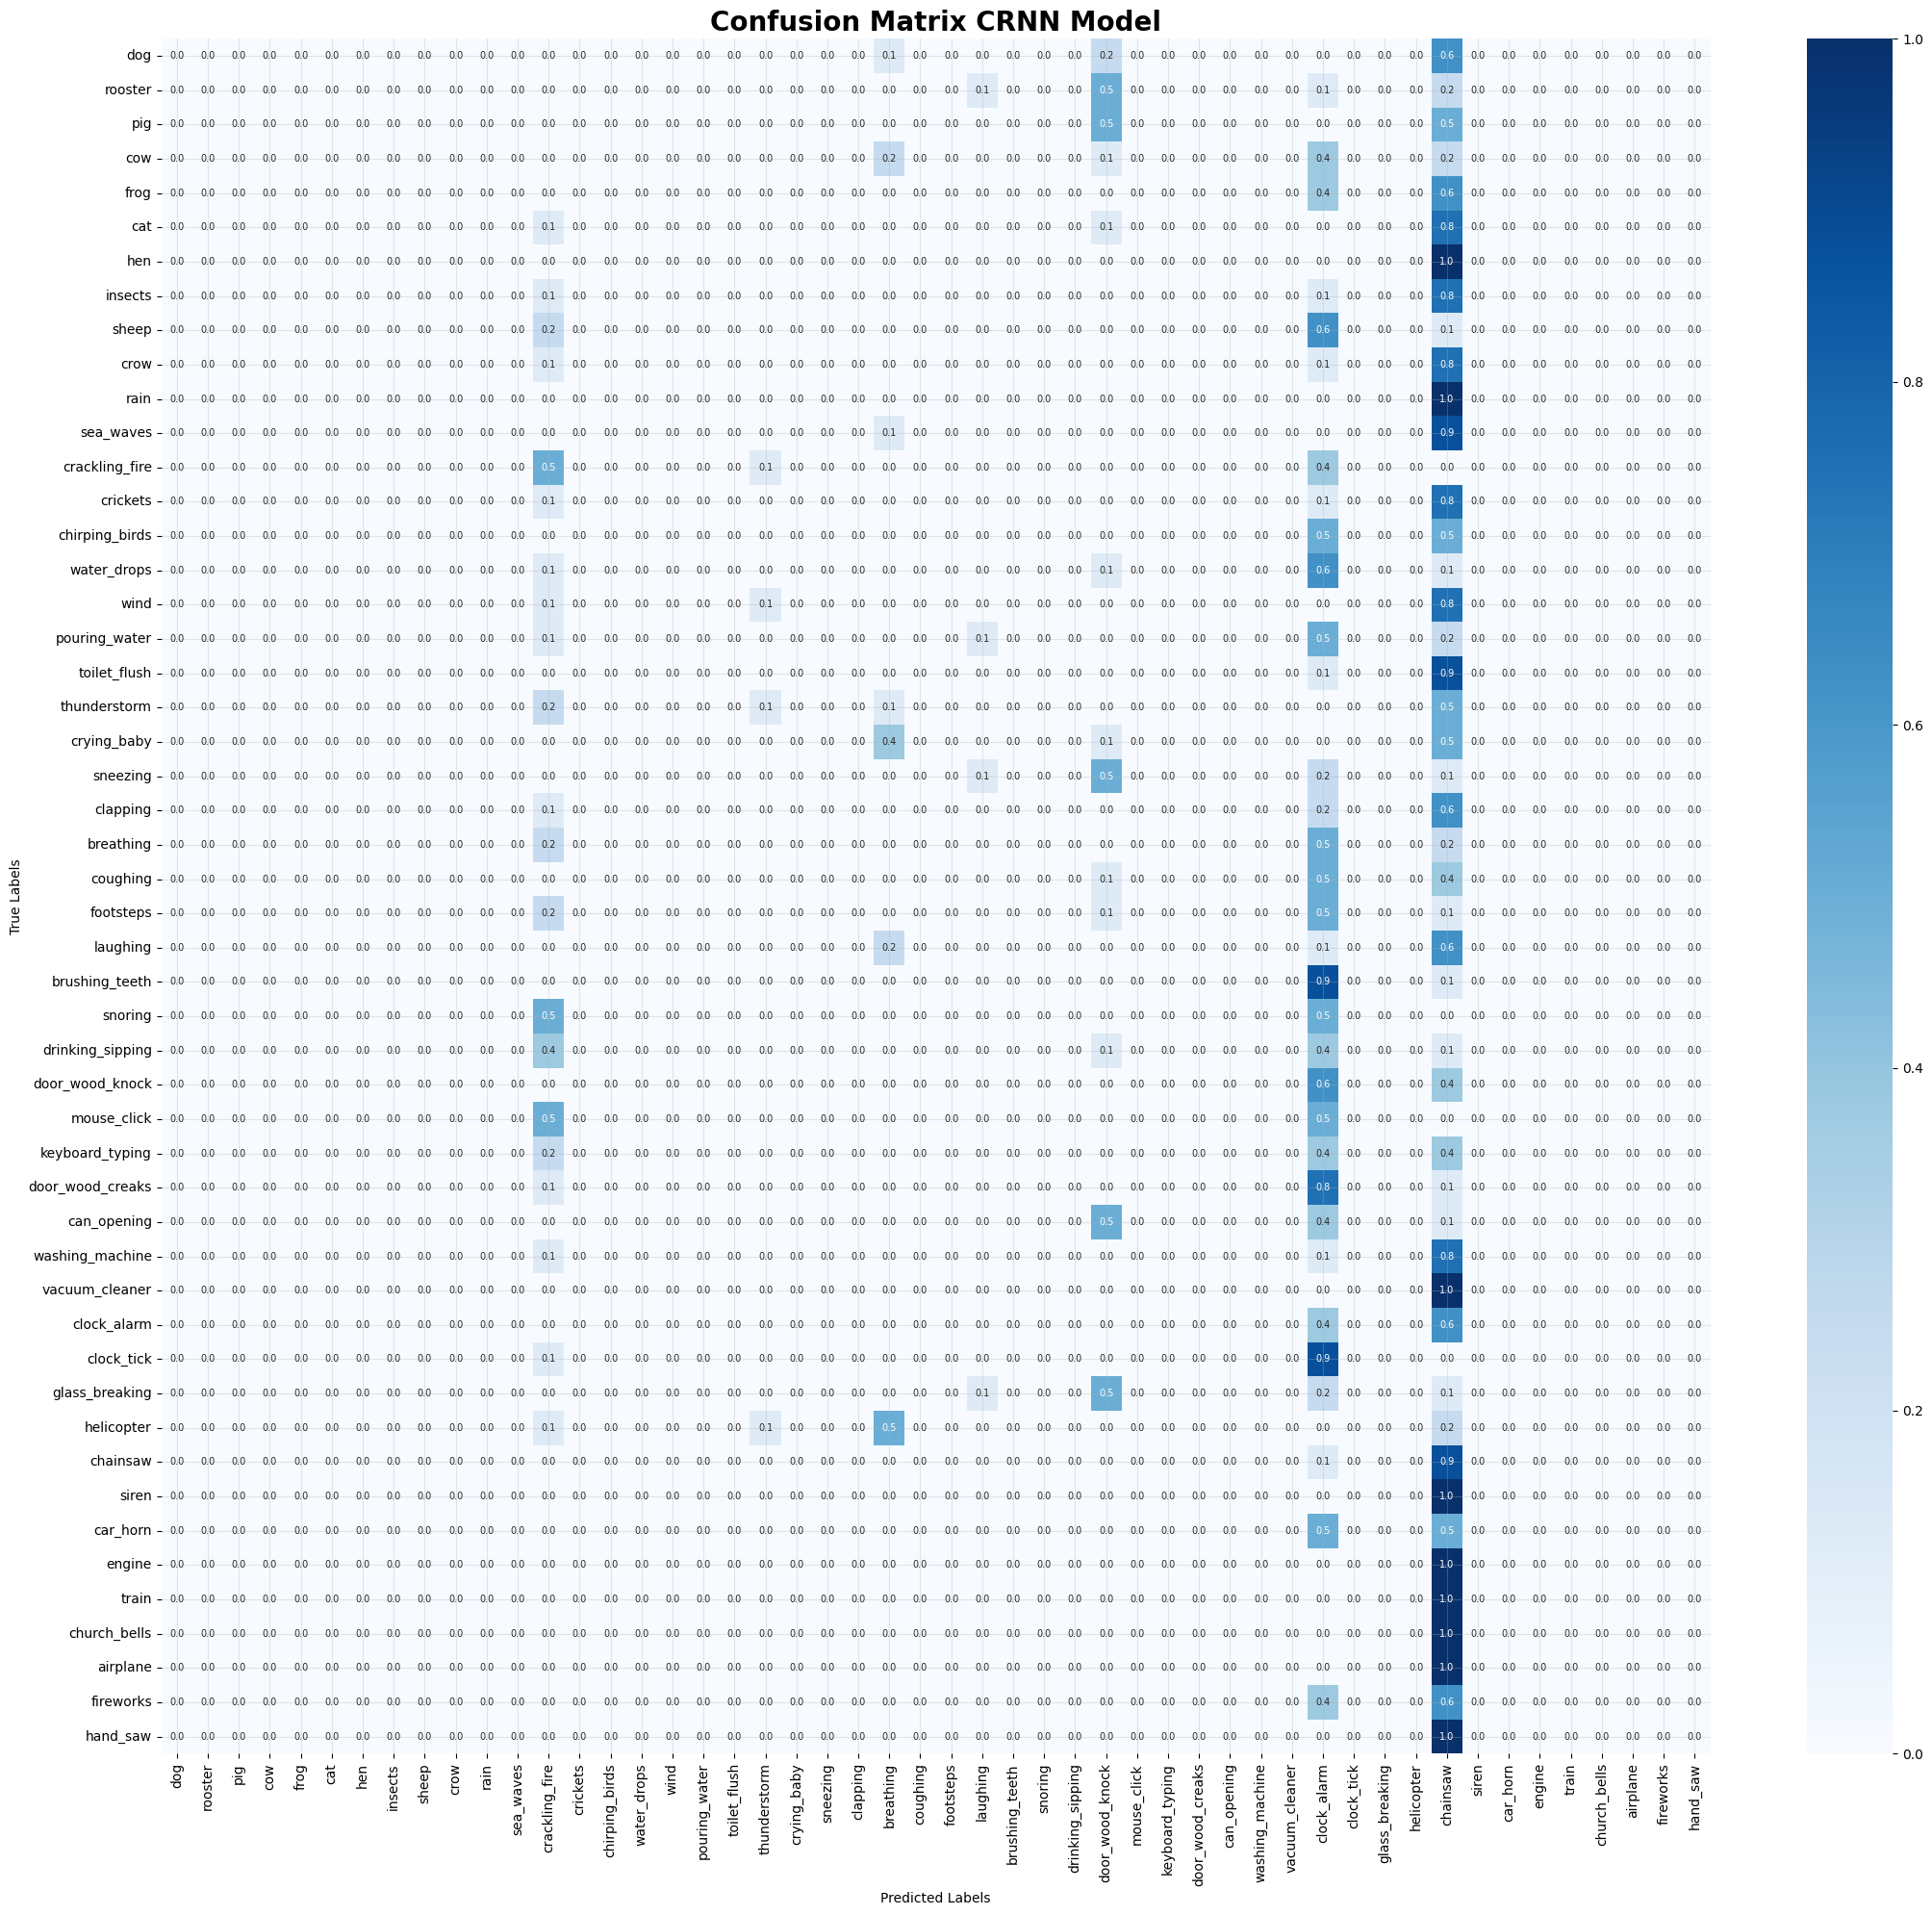

Complete saved file in CRNN_metrics.json
Completed processing metrics for CRNN
Completed extract embedding from penultimate layer of CRNN model
Embeddings saved to benchmark_embeddings_crnn.csv (Ukuran: (400, 256))
RSM saved to rsm_cosine_crnn.csv (Ukuran: (400, 400))


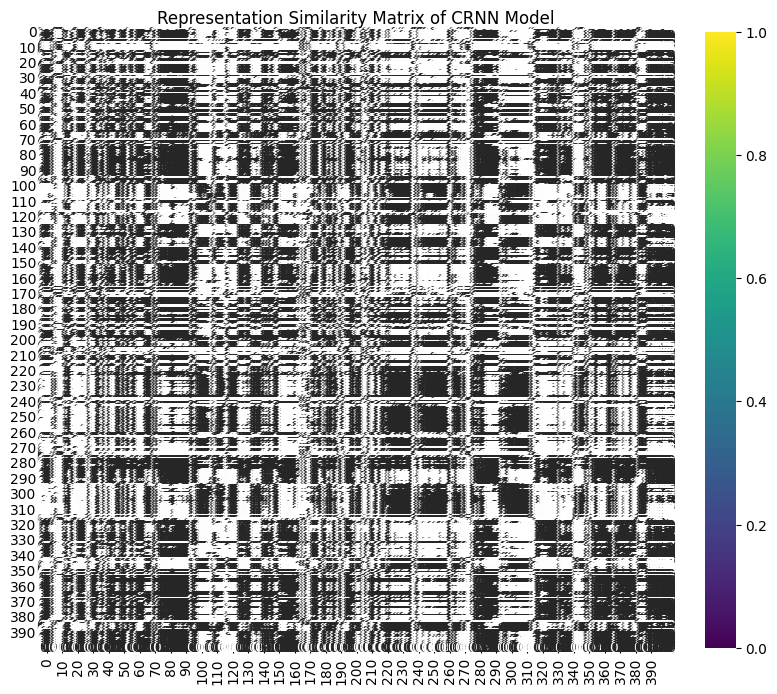

Heatmap saved to rsm_heatmap_crnn.png
Completed process of RSM calculation for CRNN model
Generating visualisation for CRNN


AttributeError: 'NoneType' object has no attribute 'data'

In [ ]:
# Overall Evaluation
models_config = [
    {
        'name': 'CRNN',
        'class': CRNN,
        'path':'CRNN_best_model.pth',
        'lr': 0.001,
        'epochs':50,
        'args': {'input_size': 64, 'hidden_size': 128, 'num_layers': 2, 'num_classes': 50}
    },
    {
        'name': 'ResNet18',
        'class': ResNet18,
        'path': 'ResNet18_best_model.pth',
        'lr': 0.001,
        'epochs':50,
        'args': {'num_classes': 50, 'pretrained': True}
    },
    {
        'name': 'ViTAudio',
        'class': ViTAudio,
        'path':'ViT_best_model.pth',
        'lr': 0.001,
        'epochs':50,
        'args': {'num_classes': 50, 'pretrained': True}
    },
]

for model_info in models_config:
  # default value
    f1 = 0.0
    best_epoch = 0
    current_best_val_acc = 0.0

    # Panggil kelas dengan argumen yang sesuai
    curr_model = model_info['class'](**model_info['args']).to(device)

    # Ambil bobot dari path
    try:
        curr_model.load_state_dict(torch.load(model_info['path'], map_location=device))

        # Evaluasi/testing
        loss, acc, all_preds, all_labels = evaluate(curr_model, test_loader, criterion, device)

        # Classification Report
        print('\nClassification Report:')
        report = classification_report(all_labels, all_preds, output_dict=True)
        f1 = report['weighted avg']['f1-score']

        # Print results
        print(f"Model: {model_info['name']}")
        print(f"Loss : {loss:.4f}")
        print(f"Accuracy: {acc:.2f}%")
        print(f"F1-score: {f1:.2f}")
        print(classification_report(all_labels, all_preds))

        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        CMVis(cm, df.sort_values('target')['category'].unique(), model_info['name'])

        # Find the best epoch based on validation accuracy from all_history
        if model_info['name'] in all_history:
            val_acc_history = all_history[model_info['name']]['val_acc']
            if val_acc_history:
                best_val_acc_overall = max(val_acc_history)
                best_epoch = val_acc_history.index(best_val_acc_overall) + 1
            else:
                best_epoch = 0 # kalau tidak terekam di validasi
        else:
            best_epoch = 0 # kalau tida ada di history


    except FileNotFoundError:
        print(f"Error: File {model_info['path']} tidak ditemukan.")
    except Exception as e:
        print(f"Error saat evaluasi {model_info['name']}: {e}")

    # Save to metrics.json
    metrics(model_info['name'], acc, f1, best_epoch, curr_model, test_loader, device)
    print(f"Completed processing metrics for {model_info['name']}")

    # Extract embeddings
    embeddings, _ = extract_embedding(curr_model, benchmark_loader, model_info['name'], device)
    print(f"Completed extract embedding from penultimate layer of {model_info['name']} model")

    # Representation Similarity Analysis
    process_and_save_rsm(embeddings, model_info['name'])
    print(f"Completed process of RSM calculation for {model_info['name']} model")

    # Saliency/Attention
    print(f"Generating visualisation for {model_info['name']}")
    sal_attn_visualization(curr_model, benchmark_loader, model_info['name'], device)
    print(f"Completed visualisation for {model_info['name']}")

    # Clear memory
    del curr_model
    torch.cuda.empty_cache()


# Bagian 7: Ekspor Folder

TODO: Script otomatis untuk membuat struktur folder sesuai halaman 11 (model_utama, model_pembanding_1, dll).
TODO: Zip semua folder untuk diunduh.